In [1]:
from torchvision import datasets,transforms
from torch.utils.data import DataLoader


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])



val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

train_data = datasets.ImageFolder("data/train", transform = train_transform)
val_data = datasets.ImageFolder("data/val", transform = val_transform)
test_data = datasets.ImageFolder("data/test", transform = test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True,num_workers=4,pin_memory = True)
val_loader = DataLoader(val_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

In [2]:
import torch
import torch.nn as nn
from torchvision import models


model = models.resnet18(pretrained=True)

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 2)
)

C:\Users\somil\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\somil\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


FREEZE conv layers for first 5 epochs

In [3]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [4]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

Train for first 5 epochs

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
train_losses = []
val_accuracies = []
epochs = 2
min_loss = float("inf")
for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for images,labels in train_loader:
        images,labels = images.to(device),labels.to(device)
         

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs,labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss/len(train_loader)
    train_losses.append(avg_loss)

    if avg_loss < min_loss:
        min_loss = avg_loss
        PATH = 'best_model.pth'
        torch.save(model.state_dict(), PATH)

  
    
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Acc={val_acc:.2f}")


        

Epoch 1: Loss=0.7549, Val Acc=52.18
Epoch 2: Loss=0.6201, Val Acc=57.88


In [6]:
# Unfreeze last layer block
for param in model.layer4.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 10

for epoch in range(2,epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss/len(train_loader)
    train_losses.append(avg_loss)
    if avg_loss < min_loss:
        min_loss = avg_loss
        PATH = 'best_model.pth'
        torch.save(model.state_dict(), PATH)

    

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Acc={val_acc:.2f}")

Epoch 3: Loss=0.3049, Val Acc=91.76
Epoch 4: Loss=0.2336, Val Acc=95.24
Epoch 5: Loss=0.2144, Val Acc=95.18
Epoch 6: Loss=0.1982, Val Acc=96.24
Epoch 7: Loss=0.1909, Val Acc=96.71
Epoch 8: Loss=0.1813, Val Acc=96.76
Epoch 9: Loss=0.1792, Val Acc=95.29
Epoch 10: Loss=0.1742, Val Acc=96.00


In [13]:

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

ps = precision_score(all_labels, all_preds)
print("Precision:", ps)

rs = recall_score(all_labels, all_preds)
print("Recall:", rs)

f1 = f1_score(all_labels, all_preds)
print("F1 Score:", f1)

Confusion Matrix:
 [[816  34]
 [ 34 816]]
Precision: 0.96
Recall: 0.96
F1 Score: 0.96


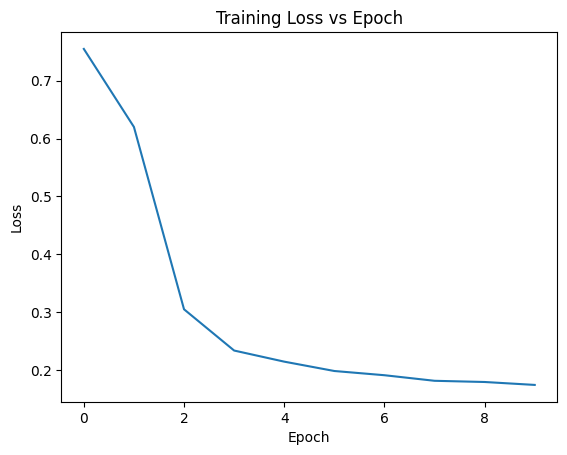

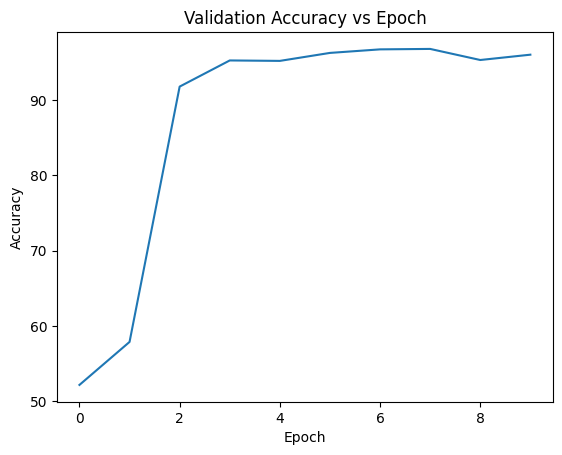

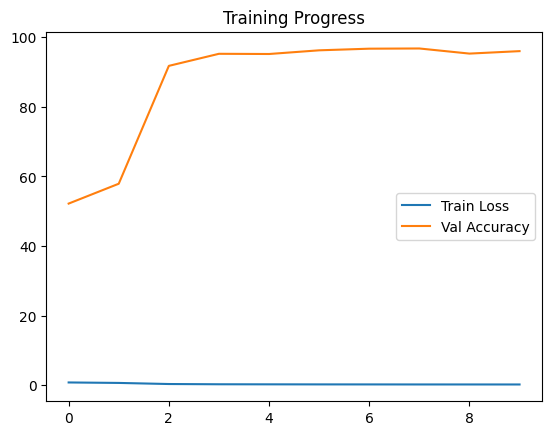

<Figure size 640x480 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt

# Loss curve
plt.plot(train_losses)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()
plt.savefig("TL vs epoch .jpg")

# Accuracy curve
plt.plot(val_accuracies)
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()
plt.savefig("val_acc.jpg")


plt.plot(train_losses, label="Train Loss")
plt.plot(val_accuracies, label="Val Accuracy")
plt.legend()
plt.title("Training Progress")
plt.show()
plt.savefig("TL vs val acc .jpg")

In [20]:


model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

test_acc = 100 * correct / total
    


print("test accuracy :" , test_acc)
print("Length of test data is " ,len(test_data))

test accuracy : 100.0
Length of test data is  30
